# Implementattion des equations de la descente de gradient

pour realiser ces taches nous allons structurer notre code de la facon suivante:
- 1 Phase d'initialisation(X) permet d'initialiser les parametres w et b de notre modele.Dans cette fonction nous ferrons passer la matrice X car notre but est d'obtnir un vecteur Y qui contient autant de parametre que l'on trouve de variable dans lamatrice X .
- 2 Algorithme iteratif pour effectuer les taches suivantes:fonction qui represente notre modele(model(X,W,b) elle va contenir notre fonction lineaire(Z=X.W+b)et la fonction d'activation(A=1/(1+exp(-Z))) )--> fonction d'evaluation ou fonction cout (Cost(A,Y) qui permettra d'evaluer les performence du modele en comparent la sortir A au donnees de reference Y) ensuite on va calculer les gradients de cette fonction cout Gradient(A,X,y)-->On va utiliser ces gradient pour mettre a jour les parametre W et b update(W,b,dW,db) de maniere a reduire les erreurs de notre modele.

In [1]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 5.6 MB/s eta 0:00:02
   -- ------------------------------------- 0.5/8.3 MB 5.6 MB/s eta 0:00:02
   -- ------------------------------------- 0.5/8.3 MB 5.6 MB/s eta 0:00:02
   -- ------------------------------------- 0.5/8.3 MB 5.6 MB/s eta 0:00:02
   -- ------------------------------------- 0.5/8.3 MB 5.6 MB/s eta 0:00:02
   -- ------------------------------------- 0.5/8.3 MB 5.6 MB/s eta 0:00:02
   ----- ---------------------------------- 1.0/8.3 MB 636.8 kB/s eta 0:00:12
   ----- ---------------------------------- 1.0/8.3 MB 636.8 kB/s eta 0:00:12
   ----- ---------------------------------- 1.0/8.3 MB 636.8 kB/s eta 0:00:12
   ------- -------------------------------- 1.6/8.3 MB 704.7 kB/s eta 0:00:10
   ------- --------------------

In [143]:
!pip install tqdm

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs,make_circles  #scikit-learn  permet de visualiser les données et de créer des ensembles de données synthétiques pour tester les algorithmes d'apprentissage automatique.
from sklearn.metrics import accuracy_score  #scikit-learn  permet de visualiser les données et de créer des ensembles de données synthétiques pour tester les algorithmes d'apprentissage automatique.
from tqdm import tqdm  #scikit-learn  permet de visualiser les données et de créer des ensembles de données synthétiques pour tester les algorithmes d'apprentissage automatique.

Dimensions de X: (100, 2)
Dimensions de y: (100, 1)


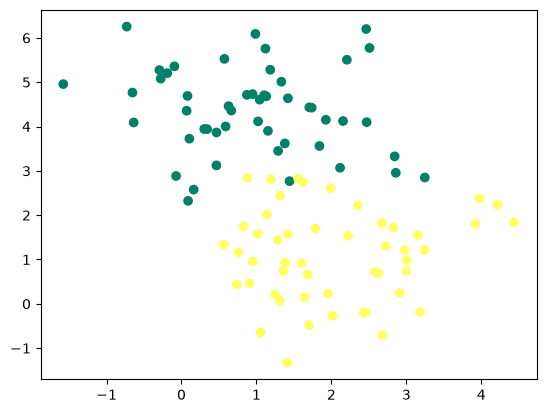

In [2]:
X,y=make_blobs(n_samples=100, n_features=2, centers=2, random_state=0) #génère un ensemble de données synthétiques avec 100 échantillons répartis en 2 clusters.
y=y.reshape((y.shape[0],1)) #redimensionne le vecteur de sortie y pour qu'il ait une forme compatible avec les opérations matricielles ultérieures.

print("Dimensions de X:",X.shape) #affiche les dimensions de la matrice X.
print("Dimensions de y:",y.shape) #affiche les dimensions du vecteur y.

plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='summer') #trace les points avec une couleur selon leur classe.
plt.show()

In [3]:
# creation de la fonction d'inaitailisation

def initialisation(X):
    W = np.random.randn(X.shape[1], 1) # Initialiser les poids avec de petites valeurs aléatoires
    b = np.random.randn(1) # Initialiser le biais avec une petite valeur aléatoire
    return W, b 

In [4]:
# Implementation de la fonction du model
def model(X, W, b):
    Z=X.dot(W) + b  # Calculer la sortie du modèle en effectuant le produit matriciel entre les entrées X et les poids W, puis en ajoutant le biais b.
    A=1/(1+np.exp(-Z))  # Appliquer la fonction d'activation  pour obtenir les probabilités de sortie A.  
    return A  # Retourner les probabilités de sortie.

In [5]:
# implementation de la fonction cout logloss
def log_loss(A, y):
    epsilon = 1e-15  # Ajouter une petite valeur epsilon pour éviter la division par zéro lors du calcul du logarithme.
    m = y.shape[0]
    loss = -(1/m) * np.sum(y * np.log(A + epsilon) + (1 - y) * np.log(1 - A + epsilon))  # Calculer la perte  en utilisant la formule de la log-loss.
    return loss  # Retourner la perte calculée

In [6]:
#Implementation des fonction de gradient 
def gradients(A, X, y):
    m = y.shape[0]
    dW = (1/m) * X.T.dot(A - y)  # Calculer le gradient des poids en utilisant la différence entre les probabilités de sortie A et les étiquettes réelles y.
    db = (1/m) * np.sum(A - y)  # Calculer le gradient du biais en utilisant la somme des différences entre A et y.
    return (dW, db)  # Retourner les gradients calculés pour les poids et le biais.

In [7]:
# Implementation de la fonction de mise à jour des paramètres
def update(W, b, dW, db, learning_rate):
    W -= learning_rate * dW  # Mettre à jour les poids en soustrayant le produit du taux d'apprentissage et du gradient des poids.
    b -= learning_rate * db  # Mettre à jour le biais en soustrayant le produit du taux d'apprentissage et du gradient du biais.
    return (W, b ) # Retourner les paramètres mis à jour.

In [8]:
# prediction
def predict(X, W, b):
    A = model(X, W, b)  # Calculer les probabilités de sortie du modèle.
    predictions = (A > 0.5).astype(int)  # Convertir les probabilités en classes (0 ou 1) en utilisant un seuil de 0.5.
    # print(A)  # Afficher les probabilités de sortie pour le nouvel échantillon.
    return predictions  # Retourner les prédictions finales.

In [10]:
def train(X, y, learning_rate=0.1, num_iterations=100):
    W, b = initialisation(X)  # Initialiser les poids et le biais.
    losses = []  # Liste pour stocker les pertes à chaque itération.
    acc=[]  # Liste pour stocker les précisions à chaque itération.

    for i in tqdm(range(num_iterations)):
        A = model(X, W, b)  # Calculer les probabilités de sortie du modèle.
        loss = log_loss(A, y)  # Calculer la perte actuelle.
        losses.append(loss)  # Ajouter la perte à la liste des pertes.
        y_pred = predict(X, W, b)  # Faire des prédictions sur les données d'entraînement.
        acc.append(accuracy_score(y, y_pred))  # Calculer et ajouter la précision actuelle à la liste des précisions.
        dW, db = gradients(A, X, y)  # Calculer les gradients des poids et du biais.
        W, b = update(W, b, dW, db, learning_rate)  # Mettre à jour les paramètres.

        if i % 100 == 0:
            print(f"Iteration {i}: Loss = {loss}, Accuracy = {acc[-1]}")  # Afficher la perte et la précision tous les 100 itérations.


    plt.figure(figsize=(12, 4))  # Créer une figure avec une taille spécifiée.
    plt.subplot(1, 2, 1)  # Créer un sous-graphique pour la perte.
    plt.plot(losses)  # Tracer la courbe de perte au fil des itérations.
    plt.xlabel("Iterations")  # Étiqueter l'axe des x.
    plt.ylabel("Loss")  # Étiqueter l'axe des y.
    plt.title("Loss over Iterations")  # Ajouter un titre au graphique.

    plt.subplot(1, 2, 2)  # Créer un sous-graphique pour la précision.
    plt.plot(acc)  # Tracer la courbe de précision au fil des itérations.
    plt.xlabel("Iterations")  # Étiqueter l'axe des x.
    plt.ylabel("Accuracy")  # Étiqueter l'axe des y.
    plt.title("Accuracy over Iterations")  # Ajouter un titre au graphique.
    plt.show()  # Afficher le graphique.

    return (W, b)  # Retourner les poids finaux, le biais et la liste des pertes.

100%|██████████| 100/100 [00:00<00:00, 1604.25it/s]


Iteration 0: Loss = 3.5009400303090463, Accuracy = 0.44


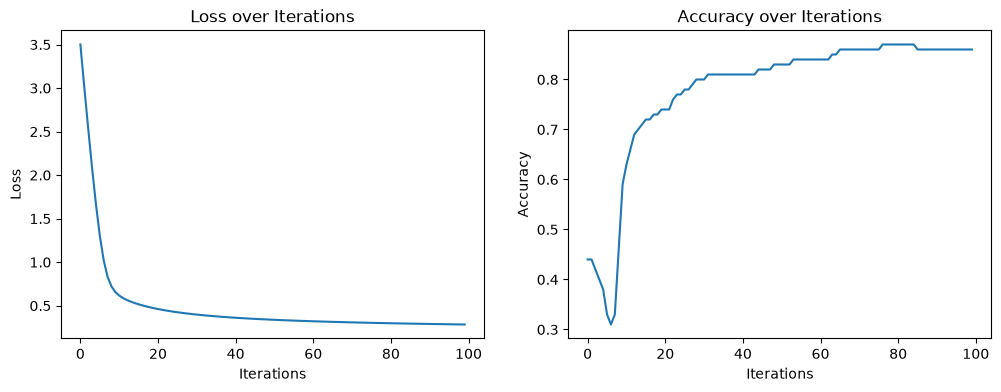

In [12]:
W, b = train(X, y, learning_rate=0.1, num_iterations=100)  # Appeler la fonction d'entraînement avec les données X et y.

[1]


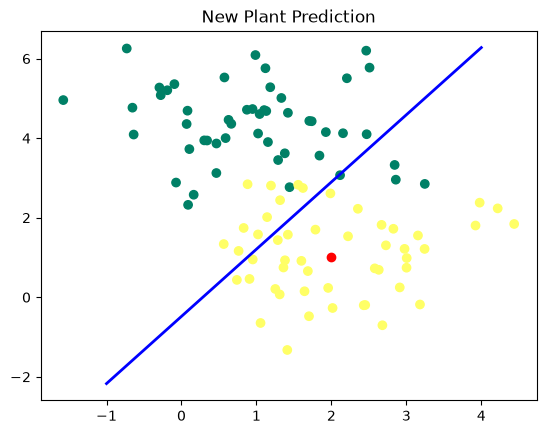

In [13]:
new_plant = np.array([2, 1])  # Définir un nouvel échantillon de plante avec des caractéristiques spécifiques.

# tracer de la frontière de décision
x0=np.linspace(-1, 4, 100)  # Générer 100 points également espacés entre -1 et 4 pour l'axe x.
x1=-(W[0]*x0+b)/W[1]  # Calculer les valeurs correspondantes de l'axe y en utilisant l'équation de la frontière de décision.

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='summer')  # Tracer les points de données d'entraînement avec une couleur selon leur classe.
plt.scatter(new_plant[0], new_plant[1], c='red')  # Tracer le nouvel échantillon de plante.
plt.plot(x0, x1, color='blue', linewidth=2)  # Tracer la frontière de décision en bleu.
plt.title("New Plant Prediction")  # Ajouter un titre au graphique
new_plant_prediction = predict(new_plant, W, b)  # Faire une prédiction pour le nouvel échantillon de plante.
print(new_plant_prediction)

# Tracage de la frontiere de decision
Elle correspond a l'ensemble des points pour lequels Z=0 car c'est l'endroit ou les probabilites sont superieur a 50 % .Car ou le point A atteint 50% le point Z est a 0
on a w1x1+w2x2+b=0


In [14]:
lin=10
h=100
w1=np.linspace(-lin, lin, h)  # Générer 100 points également espacés entre -10 et 10 pour l'axe x.
w2=np.linspace(-lin, lin, h)  # Générer 100 points également

w1, w2 = np.meshgrid(w1, w2)  # Créer une grille de points à partir des vecteurs w1 et w2.
w_final = np.c_[w1.ravel(), w2.ravel()].T  # Aplatir les grilles w1 et w2 et les combiner en une matrice de coordonnées.
w_final.shape

(2, 10000)

In [15]:
b=0
Z=X.dot(w_final)+b
A=1/(1+np.exp(-Z))

epsilon = 1e-15  # Ajouter une petite valeur epsilon pour éviter la division par zéro lors du calcul du logarithme.
m = y.shape[0]
L = -(1/m) * np.sum(y * np.log(A + epsilon) + (1 - y) * np.log(1 - A + epsilon), axis=0).reshape(w1.shape)  # Calculer la perte  en utilisant la formule de la log-loss.

L.shape

(100, 100)

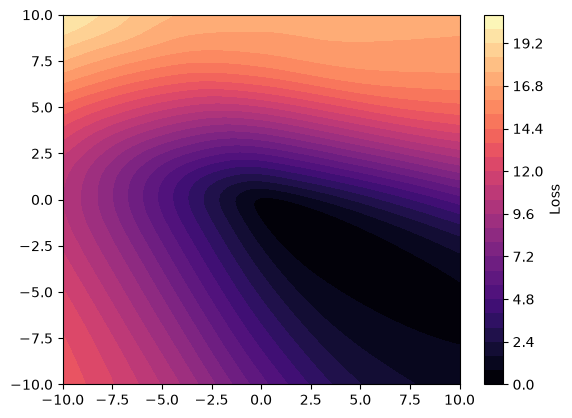

In [16]:
plt.contourf(w1, w2, L,30,cmap='magma')  # Tracer les contours de la fonction de perte L en utilisant une carte de couleurs 'viridis'.
plt.colorbar(label='Loss')  # Ajouter une b arre de couleur pour indiquer les valeurs

# Application de ce model dans la detection des chants ou des chien dans un dataset

In [64]:
!pip install h5py

   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.2 MB 5.6 MB/s eta 0:00:01
   --------- ------------------------------ 0.8/3.2 MB 8.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.8/3.2 MB 8.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.8/3.2 MB 8.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.8/3.2 MB 8.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.8/3.2 MB 8.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.8/3.2 MB 8.3 MB/s eta 0:00:01
   ---------------- ----------------------- 1.3/3.2 MB 706.1 kB/s eta 0:00:03
   ---------------- ----------------------- 1.3/3.2 MB 706.1 kB/s eta 0:00:03
   ---------------- ----------------------- 1.3/3.2 MB 706.1 kB/s eta 0:00:03
   ---------------- ----------------------- 1.3/3.2 MB 706.1 kB/s eta 0:00:03
   ------------------- -------------------- 1.6/3.2 MB 616.8 kB/s eta 0:00:03
   ------

In [58]:
# importation des data
import h5py
import numpy as np


def load_data():
    train_dataset = h5py.File('Data/trainset.hdf5', "r")
    X_train = np.array(train_dataset["X_train"][:]) # your train set features
    y_train = np.array(train_dataset["Y_train"][:]) # your train set labels

    test_dataset = h5py.File('Data/testset.hdf5', "r")
    X_test = np.array(test_dataset["X_test"][:]) # your test set features
    y_test = np.array(test_dataset["Y_test"][:]) # your test set labels
            
    return train_dataset,X_train, y_train, X_test, y_test

In [59]:
train_dataset, x_train, y_train, x_test, y_test = load_data()  # Charger les ensembles de données d'entraînement et de test à partir des fichiers HDF5.

In [54]:
print(x_train.shape)  # Afficher le nombre de caractéristiques dans l'ensemble de données d'entraînement.
print(y_train.shape)  # Afficher le nombre d'échantillons dans l'ensemble de données d'entraînement.
print(np.unique(y_train, return_counts=True))  # Afficher les classes uniques présentes dans l'ensemble de données d'entraînement.

(1000, 64, 64)
(1000, 1)
(array([0., 1.]), array([500, 500]))


In [20]:
print(x_test.shape)  # Afficher le nombre de caractéristiques dans l'ensemble de données de test.
print(y_test.shape)  # Afficher le nombre d'échantillons dans l'ensemble de données de test.
print(np.unique(y_test, return_counts=True))  # Afficher les classes uniques présentes dans l'ensemble de données de test.

(200, 64, 64)
(200, 1)
(array([0., 1.]), array([100, 100]))


In [21]:
x_train_reshape=x_train.reshape(x_train.shape[0], -1)/x_train.max()  # Redimensionner et normaliser les données d'entraînement.
x_test_reshape=x_test.reshape(x_test.shape[0], -1)/x_train.max()  # Redimensionner et normaliser les données de test.
x_train_reshape.shape
x_test_reshape.shape

(200, 4096)

In [22]:
def train_neurone(x_train, y_train, x_test, y_test, learning_rate=0.1, num_iterations=100):
    W, b = initialisation(x_train)  # Initialiser les poids et le biais.
    train_losses = []  # Liste pour stocker les pertes à chaque itération.
    train_acc = []  # Liste pour stocker les précisions à chaque itération.
    test_losses = []  # Liste pour stocker les pertes à chaque itération.
    test_acc = []  # Liste pour stocker les précisions à chaque itération.

    for i in tqdm(range(num_iterations)):
        A = model(x_train, W, b)  # Calculer les probabilités de sortie du modèle.
        if i % 10 == 0:
            # train 
            loss = log_loss(A, y_train)  # Calculer la perte actuelle.
            train_losses.append(loss)  # Ajouter la perte à la liste des pertes.
            y_pred = predict(x_train, W, b)  # Faire des prédictions sur les données d'entraînement.
            train_acc.append(accuracy_score(y_train, y_pred))  # Calculer et ajouter la précision actuelle à la liste des précisions.
            
            # test
            A_test = model(x_test, W, b)  # Calculer les probabilités de sortie du modèle pour les données de test.
            test_loss = log_loss(A_test, y_test)  # Calculer la perte actuelle.
            test_losses.append(test_loss)  # Ajouter la perte à la liste des pertes.
            y_pred = predict(x_test, W, b)  # Faire des prédictions sur les données de test.
            test_acc.append(accuracy_score(y_test, y_pred))  # Calculer et ajouter la précision actuelle à la liste des précisions.

        # Mise a jour des paramètres
        dW, db = gradients(A, x_train, y_train)  # Calculer les gradients des poids et du biais.
        W, b = update(W, b, dW, db, learning_rate)  # Mettre à jour les paramètres.

        if i % 1000 == 0:
            print(f"Iteration {i}: Loss = {loss}, Accuracy = {train_acc[-1]}")  # Afficher la perte et la précision tous les 100 itérations.





    plt.figure(figsize=(12, 4))  # Créer une figure avec une taille spécifiée.
    plt.subplot(1, 2, 1)  # Créer un sous-graphique pour la perte.
    plt.plot(train_losses)  # Tracer la courbe de perte au fil des itérations.
    plt.plot(test_losses)  # Tracer la courbe de perte de test au fil des itérations.
    plt.xlabel("Iterations")  # Étiqueter l'axe des x.
    plt.ylabel("Train Loss")  # Étiqueter l'axe des y.
    plt.title("Loss over Iterations")  # Ajouter un titre au graphique.

    plt.subplot(1, 2, 2)  # Créer un sous-graphique pour la précision.
    plt.plot(train_acc)  # Tracer la courbe de précision au fil des itérations.
    plt.plot(test_acc)  # Tracer la courbe de précision de test au fil des itérations.
    plt.xlabel("Iterations")  # Étiqueter l'axe des x.
    plt.ylabel("Accuracy")  # Étiqueter l'axe des y.
    plt.title("Accuracy over Iterations")  # Ajouter un titre au graphique.
    plt.show()  # Afficher le graphique.

    return (W, b)  # Retourner les poids finaux, le biais et la liste des pertes.

  0%|          | 50/10000 [00:00<00:38, 255.56it/s]

Iteration 0: Loss = 14.38350111640829, Accuracy = 0.491


 10%|█         | 1034/10000 [00:03<00:31, 287.43it/s]

Iteration 1000: Loss = 2.609210499513048, Accuracy = 0.564


 20%|██        | 2039/10000 [00:07<00:25, 310.17it/s]

...

 80%|████████  | 8041/10000 [00:30<00:06, 288.03it/s]

Iteration 8000: Loss = 1.1123529337796414, Accuracy = 0.681


 90%|█████████ | 9033/10000 [00:34<00:04, 228.86it/s]

Iteration 9000: Loss = 1.0134726776385627, Accuracy = 0.691


100%|██████████| 10000/10000 [00:38<00:00, 261.89it/s]


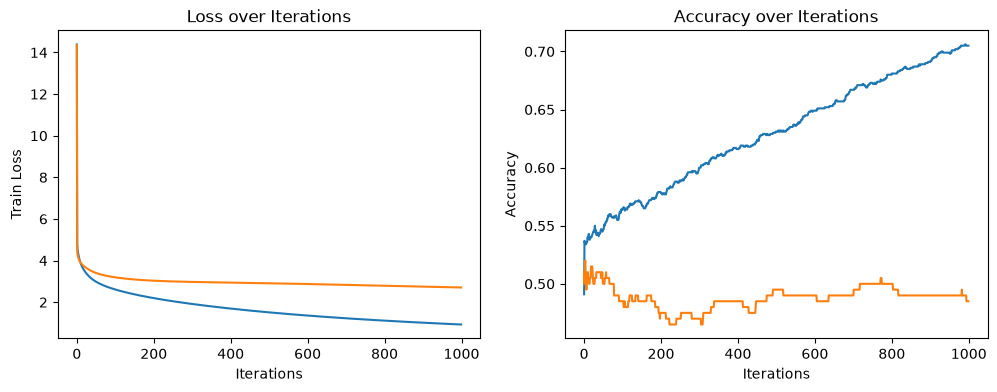

In [23]:
W,b=train_neurone(x_train_reshape, y_train, x_test_reshape, y_test, learning_rate=0.01, num_iterations=10000)  # Appeler la fonction d'entraînement avec les données d'entraînement redimensionnées et normalisées.

# Reseaux de neurone a 2 couche 


In [81]:
 # creation de la fonction d'inaitailisation

def initialisation1(n0,n1,n2):
    W1 = np.random.randn(n1, n0) # Initialiser les poids avec de petites valeurs aléatoires
    b1 = np.random.randn(n1,1) # Initialiser le biais avec une petite valeur aléatoire
    W2 = np.random.randn(n2, n1) # Initialiser les poids avec de petites valeurs aléatoires
    b2 = np.random.randn(n2,1) # Initialiser le biais avec une petite valeur aléatoire
    
    parametres={
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }
    return parametres

In [82]:
# Implementation de la fonction du model
def forward_propagation(X,parametres):
    #calcul pour les elements du premier couche
    W1=parametres["W1"]
    b1=parametres["b1"]
    Z1=W1.dot(X) + b1  # Calculer la sortie du modèle en effectuant le produit matriciel entre les entrées X et les poids W, puis en ajoutant le biais b.
    A1=1/(1+np.exp(-Z1))  # Appliquer la fonction d'activation sigmoïde pour obtenir les probabilités de sortie A1.
    

    #calcul pour les elements du premier couche
    W2=parametres["W2"]
    b2=parametres["b2"]
    Z2=W2.dot(A1) + b2  # Calculer la sortie du modèle en effectuant le produit matriciel entre les entrées X et les poids W, puis en ajoutant le biais b.
    A2=1/(1+np.exp(-Z2))  # Appliquer la fonction d'activation sigmoïde pour obtenir les probabilités de sortie A2.
    
    activations={
        "A1": A1,   
        "A2": A2
    }
    return activations

In [83]:
#Implementation des fonction de gradient 
def back_propagation(X, y, activations, parametres):
    A1 = activations["A1"]
    A2 = activations["A2"]
    W2 = parametres["W2"]
    m = y.shape[1]

    # Calculer les gradients pour la couche cachee(couche2)
    dZ2 = A2 - y
    dW2 = (1/m) * dZ2.dot(A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True) # Calculer le gradient du biais pour la couche de sortie en utilisant la somme des différences entre A2 et y.
    
    # Calculer les gradients pour la couche d'entree(couche1)
    dZ1 = W2.T.dot(dZ2) * A1 * (1 - A1)
    dW1 = (1/m) * dZ1.dot(X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    
    gradients = {
        "dW1": dW1, 
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }
    return gradients

In [84]:
# Implementation de la fonction de mise à jour des paramètres
def update1(gradients ,parametres, learning_rate):

    W1 = parametres["W1"]
    b1 = parametres["b1"]
    W2 = parametres["W2"]
    b2 = parametres["b2"]

    W1=W1-learning_rate * gradients["dW1"]  # Mettre à jour les poids en soustrayant le produit du taux d'apprentissage et du gradient des poids.
    b1=b1-learning_rate * gradients["db1"]  # Mettre à jour le biais en soustrayant le produit du taux d'apprentissage et du gradient du biais.
    W2=W2-learning_rate * gradients["dW2"]  # Mettre à jour les poids en soustrayant le produit du taux d'apprentissage et du gradient des poids.
    b2=b2-learning_rate * gradients["db2"]  # Mettre à jour le biais en soustrayant le produit du taux d'apprentissage et du gradient du biais.
   
    parametres={
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }
    return parametres

In [85]:
# prediction
def predict1(X, parametres):
    activations= forward_propagation(X, parametres)  # Calculer les probabilités de sortie du modèle.
    A2=activations["A2"]  # Récupérer les probabilités de sortie de la couche de sortie.
    predictions = (A2 > 0.5).astype(int)  # Convertir les probabilités en classes (0 ou 1) en utilisant un seuil de 0.5.
    return predictions  # Retourner les prédictions finales.

In [87]:
def neural_network(X_train, y_train,n1, learning_rate=0.1, num_iterations=100):

    n0=X_train.shape[0]  # Nombre de caractéristiques d'entrée.
    n2=y_train.shape[0]  # Nombre de classes de sortie.
    parametres = initialisation1(n0,n1,n2)  # Initialiser les poids et le biais.

    losses = []  # Liste pour stocker les pertes à chaque itération.
    acc=[]  # Liste pour stocker les précisions à chaque itération.

    for i in tqdm(range(num_iterations)):
        activations= forward_propagation(X_train, parametres)  # Calculer les probabilités de sortie du modèle.
        gradients = back_propagation(X_train, y_train, activations, parametres)  # Calculer les gradients des poids et du biais.
        parametres = update1(gradients, parametres, learning_rate)  # Mettre à jour les paramètres.
        if i % 10 == 0:
            loss = log_loss(activations["A2"],y_train)  # Calculer la perte actuelle.
            losses.append(loss)  # Ajouter la perte à la liste des pertes.
            y_pred = predict1(X_train, parametres)  # Faire des prédictions sur les données d'entraînement.
            acc.append(accuracy_score(y_train.flatten(), y_pred.flatten()))  # Calculer et ajouter la précision actuelle à la liste des précisions.
 
    plt.figure(figsize=(12, 4))  # Créer une figure avec une taille spécifiée.
    plt.subplot(1, 2, 1)  # Créer un sous-graphique pour la perte.
    plt.plot(losses)  # Tracer la courbe de perte au fil des itérations.
    plt.xlabel("Iterations")  # Étiqueter l'axe des x.
    plt.ylabel("Loss")  # Étiqueter l'axe des y.
    plt.title("Loss over Iterations")  # Ajouter un titre au graphique.

    plt.subplot(1, 2, 2)  # Créer un sous-graphique pour la précision.
    plt.plot(acc)  # Tracer la courbe de précision au fil des itérations.
    plt.xlabel("Iterations")  # Étiqueter l'axe des x.
    plt.ylabel("Accuracy")  # Étiqueter l'axe des y.
    plt.title("Accuracy over Iterations")  # Ajouter un titre au graphique.
    plt.show()  # Afficher le graphique.

    return parametres  # Retourner les poids finaux, le biais et la liste des pertes.

Dimensions de X: (100, 2)
Dimensions de y: (100, 1)


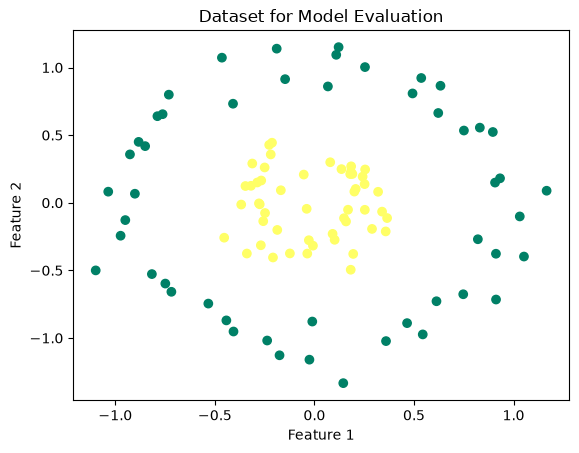

In [88]:
# creation du datasset pour l'evaluation du model
X,y=make_circles(n_samples=100, noise=0.1, random_state=0,factor=0.3)  # Générer un ensemble de données synthétiques en forme de cercles avec 100 échantillons et 2 caractéristiques.
y=y.reshape((y.shape[0],1))  # Redimensionner le vecteur

print("Dimensions de X:",X.shape)  # Afficher les dimensions de la matrice X.
print("Dimensions de y:",y.shape)  # Afficher les dimensions du vecteur y

plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='summer')  # Tracer les points avec une couleur selon leur classe.
plt.xlabel("Feature 1")  # Étiqueter l'axe des x.
plt.ylabel("Feature 2")  # Étiqueter l'axe des y.
plt.title("Dataset for Model Evaluation")  # Ajouter un titre au graphique.
plt.show()  # Afficher le graphique.

 35%|███▍      | 348/1000 [00:00<00:00, 1750.59it/s]

Iteration 0: Loss = 0.833033874292002, Accuracy = 0.5
Iteration 100: Loss = 0.6954644762945056, Accuracy = 0.66
Iteration 200: Loss = 0.6931313619207307, Accuracy = 0.5
Iteration 300: Loss = 0.6928433644739687, Accuracy = 0.47


 71%|███████   | 708/1000 [00:00<00:00, 1782.95it/s]

Iteration 400: Loss = 0.6927836494570447, Accuracy = 0.51
Iteration 500: Loss = 0.6927709842397209, Accuracy = 0.5
Iteration 600: Loss = 0.6927682905077442, Accuracy = 0.52
Iteration 700: Loss = 0.6927677160532987, Accuracy = 0.52


100%|██████████| 1000/1000 [00:00<00:00, 1767.80it/s]


Iteration 800: Loss = 0.6927675931638482, Accuracy = 0.52
Iteration 900: Loss = 0.6927675667790796, Accuracy = 0.52


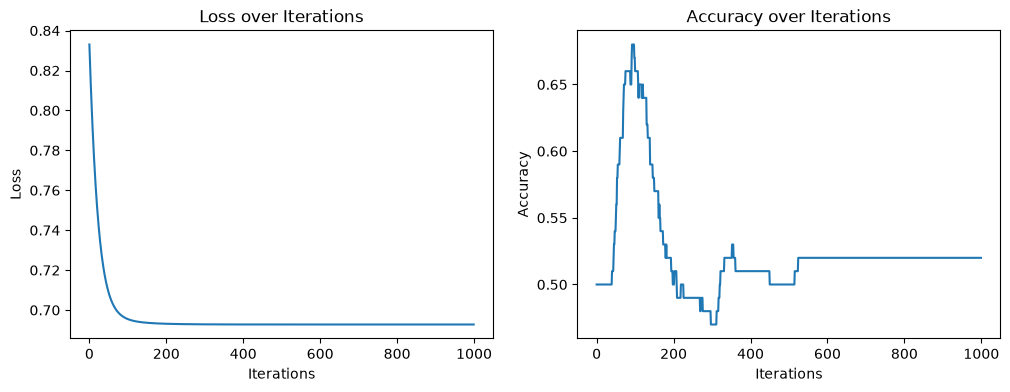

In [90]:
W,b=train(X,y, learning_rate=0.1, num_iterations=1000)  # Appeler la fonction d'entraînement avec les données X et y.

Dimensions de X: (2, 100)
Dimensions de y: (1, 100)


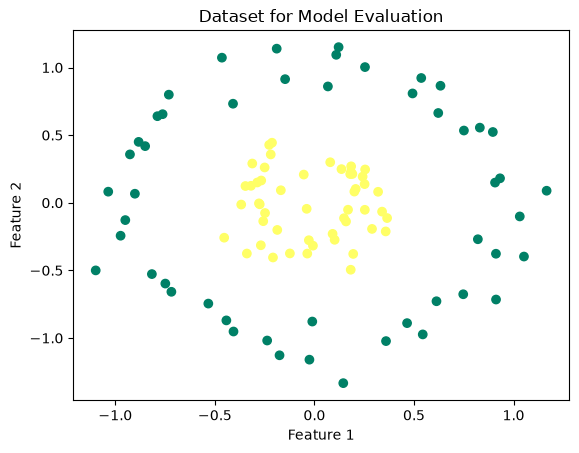

In [91]:
# creation du datasset pour l'evaluation du model
X,y=make_circles(n_samples=100, noise=0.1, random_state=0,factor=0.3)  # Générer un ensemble de données synthétiques en forme de cercles avec 100 échantillons et 2 caractéristiques.
X=X.T
y=y.reshape((1,y.shape[0]))  # Redimensionner le vecteur

print("Dimensions de X:",X.shape)  # Afficher les dimensions de la matrice X.
print("Dimensions de y:",y.shape)  # Afficher les dimensions du vecteur y

plt.scatter(X[0, :], X[1, :], c=y.ravel(), cmap='summer')  # Tracer les points avec une couleur selon leur classe.
plt.xlabel("Feature 1")  # Étiqueter l'axe des x.
plt.ylabel("Feature 2")  # Étiqueter l'axe des y.
plt.title("Dataset for Model Evaluation")  # Ajouter un titre au graphique.
plt.show()  # Afficher le graphique.

100%|██████████| 1000/1000 [00:00<00:00, 8668.75it/s]


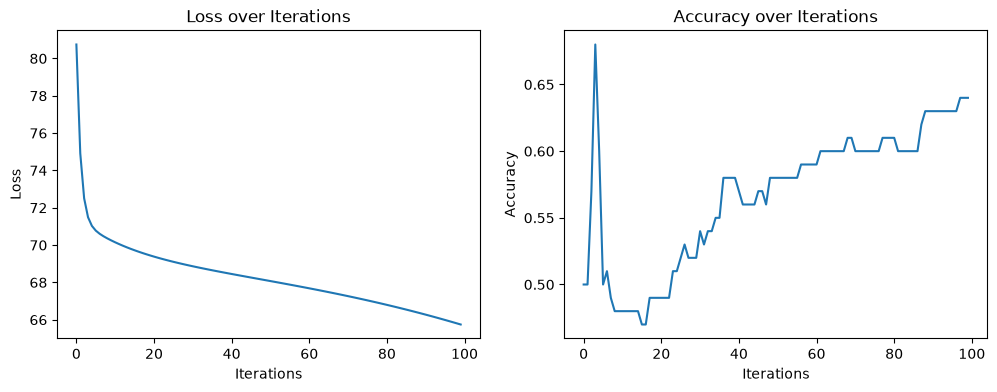

In [143]:
parametres=neural_network(X,y, n1=6, learning_rate=0.1, num_iterations=1000)  # Appeler la fonction d'entraînement du réseau de neurones avec les données X et y, en spécifiant le nombre de neurones dans la couche cachée, le taux d'apprentissage et le nombre d'itérations.

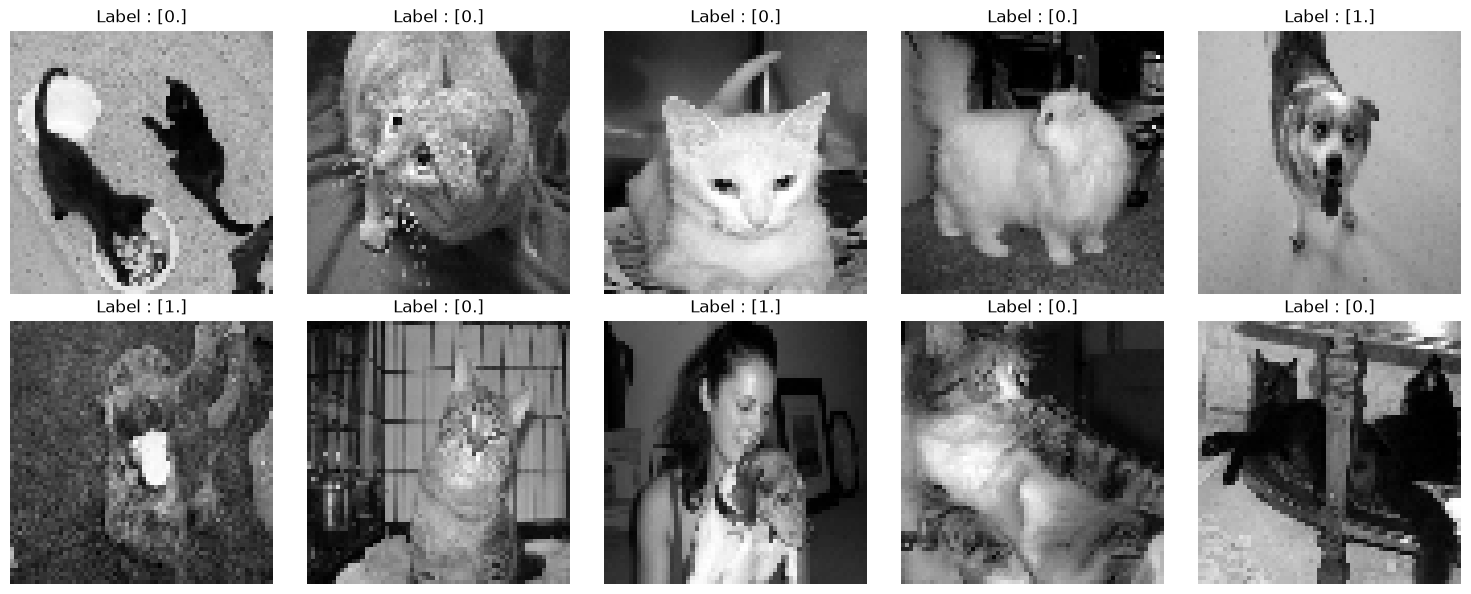

In [144]:
# Afficher les 10 premières images
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')  # Afficher l'image en niveaux de gris.
    plt.title(f"Label : {y_train[i]}")
    plt.axis("off")

plt.tight_layout()

100%|██████████| 1000/1000 [00:18<00:00, 54.78it/s]


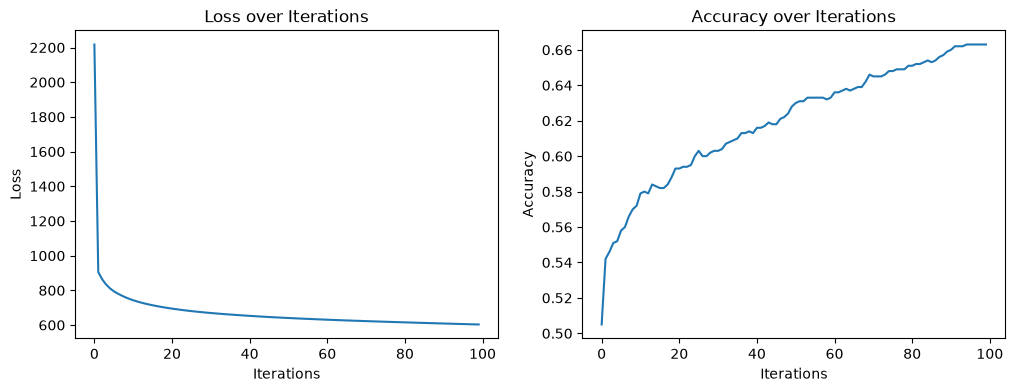

In [219]:
parametres1=neural_network(x_train_reshape.T,y_train.T, n1=32, learning_rate=0.1, num_iterations=1000)  # Appeler la fonction d'entraînement du réseau de neurones avec les données d'entraînement redimensionnées et normalisées.

In [225]:
# Testons le modele sur une image exterieure
from PIL import Image
import numpy as np

# Charger l'image
image = Image.open("img3.webp")  # Remplacez "image.jpg" par le chemin de votre image.
# Redimensionner (exemple : 64x64)
image1 = image.resize((64, 64)).convert("L")  # Redimensionner l'image à 64x64 pixels et la convertir en niveaux de gris.

# Convertir en tableau NumPy
image_array = np.array(image1)
print(image_array.shape)


(64, 64)


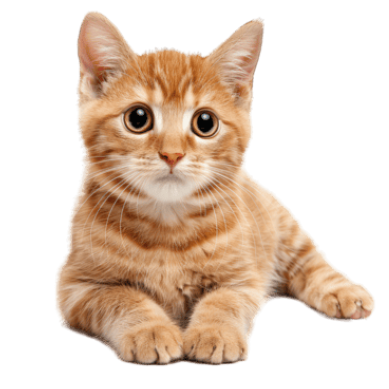

[[0]]
L'image represente  un chat .


C:\Users\PC\AppData\Local\Temp\ipykernel_25344\4023325505.py:7: RuntimeWarning: overflow encountered in exp
  A1=1/(1+np.exp(-Z1))  # Appliquer la fonction d'activation sigmoïde pour obtenir les probabilités de sortie A1.


In [227]:
plt.imshow(image)  # Afficher l'image originale.
plt.axis("off")  # Supprimer les axes pour une meilleure visualisation.
plt.show()  # Afficher l'image.
prediction = predict1(image_array.reshape(-1, 1), parametres1)  # Faire une prédiction sur l'image redimensionnée en utilisant le modèle entraîné.
print(prediction)  # Afficher la prédiction (0 ou 1) pour l'image testée.
if prediction == 1:
    print("L'image represente un chien .")
elif prediction == 0:
    print("L'image represente  un chat .")
else:
    print("Prédiction inconnue.")

# Creation d'un modele contenat plus de deux couches

In [232]:
# Fonction d'initialisation pour un réseau de neurones à plusieurs couches
def initialisation_multi_couche(dimensions):
    C=len(dimensions)
    parametres={}
    for c in range(1,C):
        parametres["W"+str(c)] = np.random.randn(dimensions[c], dimensions[c-1])# Initialiser les poids avec de petites valeurs aléatoires.
        parametres["b"+str(c)] = np.zeros((dimensions[c], 1))  # Initialiser le biais avec des zéros.
    return parametres

In [233]:
# Test de la fonction initialisation_multi_couche
parametres2 = initialisation_multi_couche([2,32,32,1])  # Appeler la fonction d'initialisation avec les dimensions spécifiées pour créer un réseau de neurones à 3 couches.

for key ,val in parametres2.items():
    print(f"{key}: {val.shape}")  # Afficher les dimensions des poids et des biais pour chaque couche du réseau de neurones.    

W1: (32, 2)
b1: (32, 1)
W2: (32, 32)
b2: (32, 1)
W3: (1, 32)
b3: (1, 1)


In [234]:
# Fonction de forward pour un réseau de neurones à plusieurs couches
def forward_propagation_multi_couche(X,parametres):
    activations={'A0': X}  # Stocker les activations de la couche d'entrée.
    C=len(parametres)//2  # Calculer le nombre de couches dans le réseau de neurones.
    for c in range(1,C+1):
        W=parametres["W"+str(c)]  # Récupérer les poids pour la couche c.
        b=parametres["b"+str(c)]  # Récupérer le biais pour la couche c.
        Z=W.dot(activations["A"+str(c-1)]) + b  # Calculer la sortie linéaire Z pour la couche c.
        A=1/(1+np.exp(-Z))  # Appliquer la fonction d'activation sigmoïde pour obtenir les probabilités de sortie A.
        activations["A"+str(c)]=A  # Stocker les activations de la couche c.
    return activations

In [235]:
# test de la fonction forward_propagation_multi_couche
activations2 = forward_propagation_multi_couche(X, parametres2)
for key ,val in activations2.items():
    print(f"{key}: {val.shape}")  # Afficher les dimensions des activations pour chaque couche du réseau de neurones.

A0: (2, 100)
A1: (32, 100)
A2: (32, 100)
A3: (1, 100)


In [237]:
#Implementation des fonction de gradient pour un réseau de neurones à plusieurs couches
def back_propagation_multi_couche(y, activations, parametres):
    gradients = {}
    m=y.shape[1]  # Nombre d'échantillons.
    C=len(parametres)//2  # Calculer le nombre de couches dans le réseau
    dZ = activations["A"+str(C)]-y   # Calculer la dérivée de l'erreur par rapport à la sortie du réseau

    for c in reversed(range(1, C+1)):
        A = activations["A"+str(c-1)]  # Récupérer les activations de la couche précédente
        W = parametres["W"+str(c)]  # Récupérer les poids de la couche actuelle
        dW = (1/m) * dZ.dot(A.T)  # Calculer le gradient des poids
        db = (1/m) * np.sum(dZ, axis=1, keepdims=True)  # Calculer le gradient du biais
        gradients["dW"+str(c)] = dW
        gradients["db"+str(c)] = db
        if c > 1:  # Si ce n'est pas la première couche, calculer dZ pour la couche précédente
            dZ = W.T.dot(dZ) * A * (1 - A)  # Calculer la dérivée de l'erreur pour la couche précédente
    return gradients

In [238]:
# test de la fonction back_propagation_multi_couche
gradients2 = back_propagation_multi_couche(y, activations2, parametres2)
for key ,val in gradients2.items():
    print(f"{key}: {val.shape}")  # Afficher les dimensions des gradients pour chaque couche du réseau de neurones.

dW3: (1, 32)
db3: (1, 1)
dW2: (32, 32)
db2: (32, 1)
dW1: (32, 2)
db1: (32, 1)


In [239]:
# Implementation de la fonction de mise à jour des paramètres
def update_multi_couche(gradients ,parametres, learning_rate):

    C=len(parametres)//2  # Calculer le nombre de couches dans le réseau
    for c in range(1,C+1):  
        parametres["W"+str(c)] = parametres["W"+str(c)] - learning_rate * gradients["dW"+str(c)]  # Mettre à jour les poids pour la couche c
        parametres["b"+str(c)] = parametres["b"+str(c)] - learning_rate * gradients["db"+str(c)]  # Mettre à jour le biais pour la couche c
    return parametres

In [248]:
def predict_image(image_path, parametres):
    # Charger l'image
    image = Image.open(image_path)  # Remplacez "image.jpg" par le chemin de votre image.
    # Redimensionner (exemple : 64x64)
    image1 = image.resize((64, 64)).convert("L")  # Redimensionner l'image à 64x64 pixels et la convertir en niveaux de gris.

    # Convertir en tableau NumPy
    image_array = np.array(image1).reshape(-1, 1) / 255.0  # Redimensionner et normaliser l'image.

    activations = forward_propagation_multi_couche(image_array, parametres)  # Effectuer la propagation avant pour obtenir les activations.
    A_final = activations["A" + str(len(parametres) // 2)]  # Récupérer les activations de la dernière couche.
    prediction = (A_final > 0.5).astype(int)  # Convertir les probabilités en classes (0 ou 1) en utilisant un seuil de 0.5.

    return prediction

In [245]:
def neural_network_multi_couche(X,y,hidden_layers=(32,32,32), learning_rate=0.1, num_iterations=1000):
    np.random.seed(0)  # Fixer la graine pour la reproductibilité des résultats.
    
    #initialisation w et b
    dimensions=list(hidden_layers)  # Convertir les couches cachées en liste.
    dimensions.insert(0, X.shape[0])  # Ajouter le nombre de caractéristiques de l'entrée.
    dimensions.append(y.shape[0])  # Ajouter le nombre de classes de sortie.
    parametres = initialisation_multi_couche(dimensions)  # Initialiser les poids et le biais.
    train_losses = []  # Liste pour stocker les pertes à chaque itération.
    train_acc = []  # Liste pour stocker les précisions à chaque itération.

    for i in tqdm(range(num_iterations)):
        activations = forward_propagation_multi_couche(X, parametres)  # Calculer les probabilités de sortie du modèle.
        gradients = back_propagation_multi_couche(y, activations, parametres)  # Calculer les gradients des poids et du biais.
        parametres = update_multi_couche(gradients, parametres, learning_rate)  # Mettre à jour les paramètres.

        if i % 10 == 0:
            C=len(parametres)//2  # Calculer le nombre de couches dans le réseau.
            loss = log_loss(y, activations["A" + str(C)])  # Calculer la perte actuelle.
            train_losses.append(loss)  # Ajouter la perte à la liste des pertes.
            y_pred = (activations["A" + str(C)] > 0.5).astype(int)  # Faire des prédictions sur les données d'entraînement.
            train_acc.append(accuracy_score(y.flatten(), y_pred.flatten()))  # Calculer et ajouter la précision actuelle à la liste des précisions.

    plt.figure(figsize=(12, 4))  # Créer une figure avec une taille spécifiée.
    plt.subplot(1, 2, 1)  # Créer un sous-graphique pour la perte.
    plt.plot(train_losses)  # Tracer la courbe de perte au fil des itérations.
    plt.xlabel("Iterations")  # Étiqueter l'axe des x.
    plt.ylabel("Loss")  # Étiqueter l'axe des y.
    plt.title("Loss over Iterations")  # Ajouter un titre au graphique.

    plt.subplot(1, 2, 2)  # Créer un sous-graphique pour la précision.
    plt.plot(train_acc)  # Tracer la courbe de précision au fil des itérations.
    plt.xlabel("Iterations")  # Étiqueter l'axe des x.
    plt.ylabel("Accuracy")  # Étiqueter l'axe des y.
    plt.title("Accuracy over Iterations")  # Ajouter un titre au graphique.
    plt.show()  # Afficher le graphique.
    
    return parametres  # Retourner les poids finaux, le biais et la liste des pertes.

100%|██████████| 1000/1000 [00:00<00:00, 3115.20it/s]


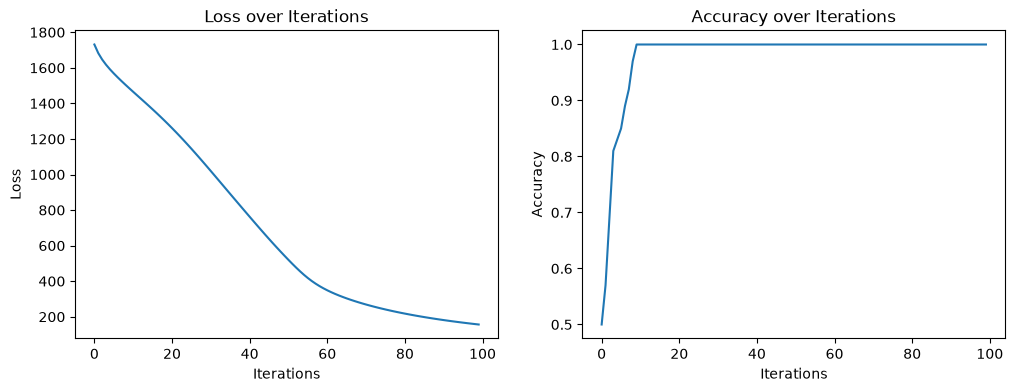

{'W1': array([[ 1.98316714,  0.52670253],
        [ 1.12678082,  2.24990818],
        [ 1.94515074, -1.23936248],
        [ 1.27464978,  0.09130196],
        [-0.21621399,  0.77007108],
        [ 0.13435891,  1.61150389],
        [ 0.78596869,  0.36893214],
        [ 0.1117978 ,  0.73880379],
        [ 1.47726798, -0.32953829],
        [ 0.46481482, -1.336861  ],
        [-2.5839108 ,  0.75640226],
        [ 1.28822576, -0.77418495],
        [ 2.41784126, -1.48818061],
        [ 0.2455675 , -0.67115532],
        [ 1.68559055,  1.51968251],
        [ 0.59876198,  0.66113793],
        [-1.17308625, -2.09527214],
        [-0.66656417,  1.10479488],
        [ 1.13309568,  1.35009663],
        [-0.33982674, -0.3419939 ],
        [-1.19582705, -1.50055692],
        [-1.96102903,  1.87887624],
        [-0.32352126, -0.95620842],
        [-1.42887716,  0.61150932],
        [-1.81108952, -0.14204956],
        [-1.08939322,  0.30697705],
        [-0.68578952, -1.07144057],
        [-0.24474436, 

In [243]:
neural_network_multi_couche(X, y, hidden_layers=(32, 32, 32), learning_rate=0.1, num_iterations=1000)  # Appeler la fonction d'entraînement du réseau de neurones multi-couches avec les données X et y, en spécifiant les couches cachées, le taux d'apprentissage et le nombre d'itérations.

100%|██████████| 1000/1000 [00:31<00:00, 31.69it/s]


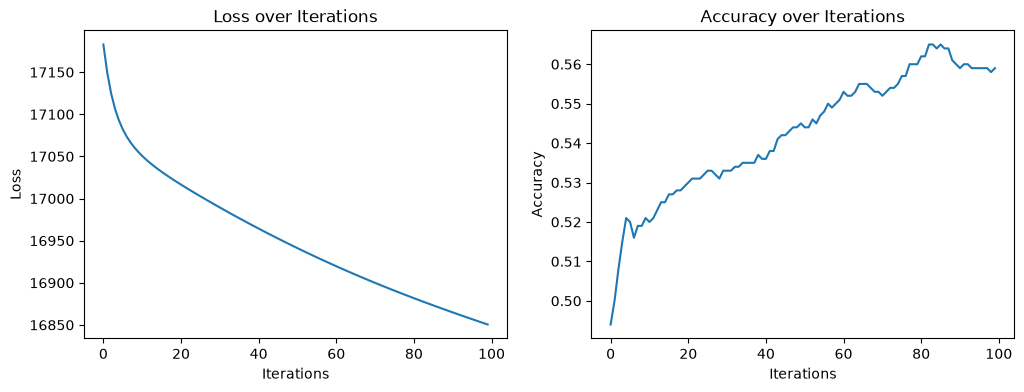

In [256]:
parametres_multi_couche = neural_network_multi_couche(x_train_reshape.T, y_train.T, hidden_layers=(64, 32, 16), learning_rate=0.01, num_iterations=1000)  # Appeler la fonction d'entraînement du réseau de neurones multi-couches avec les données d'entraînement redimensionnées et normalisées.

In [257]:
prediction_multi_couche = predict_image("img3.webp", parametres_multi_couche)  # Faire une prédiction sur l'image testée en utilisant le modèle multi-couches entraîné.


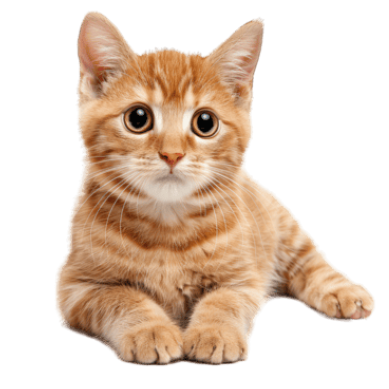

[[0]]
L'image represente  un chat .


In [258]:
plt.imshow(image)  # Afficher l'image originale.
plt.axis("off")  # Supprimer les axes pour une meilleure visualisation.
plt.show()  # Afficher l'image.
print(prediction_multi_couche)  # Afficher la prédiction (0 ou 1) pour l'image testée.
if prediction_multi_couche == 1:
    print("L'image represente un chien .")
elif prediction_multi_couche == 0:
    print("L'image represente  un chat .")
else:
    print("Prédiction inconnue.")